# Análise de Sinistros nas Rodovias Federais do Brasil

**Integrantes:** Andre Luis Soares Ferreira, Helena Couto dos Santos, Juliana Fernandes Barreto, Mariana Esthefany Xavier dos Santos

## Introdução

Sinistros de trânsito nas rodovias federais respondem por parte significativa das mortes evitáveis
no Brasil, e boa parte do debate público sobre segurança viária foca em fatores da via ou do
condutor, dando menos atenção às características do próprio veículo. Este trabalho investiga se
veículos com melhor avaliação de segurança (Latin NCAP) e maior valor médio de mercado (Tabela
FIPE) estão associados a menor gravidade entre os envolvidos em sinistros nas rodovias federais do
Brasil.

A análise cruza os Dados Abertos da Polícia Rodoviária Federal (PRF), que registram cada sinistro
por ocorrência, por pessoa envolvida e por veículo, com informações externas de segurança veicular
do Latin NCAP e de valor de mercado da Tabela FIPE, obtidas por normalização e casamento do campo de
marca/modelo informado pela PRF.

O recorte é nacional (rodovias federais do Brasil) e temporal (2010 a 2026, sendo 2026 um ano ainda
incompleto na base, tratado separadamente nas análises de tendência). A abordagem é associativa, não
causal: o objetivo é descrever padrões e proporções observadas na base, não isolar o efeito de
nenhuma variável sobre a gravidade dos sinistros, nem estimar risco por exposição ao tráfego. Os
resultados também não representam a frota completa de veículos leves do país, apenas os veículos e
sinistros presentes neste recorte enriquecido.

Ao longo do relatório, oito perguntas orientam a análise:

1. Como o volume e a proporção de pessoas com desfecho grave/fatal evoluíram ao longo do período?
2. Em quais combinações de dia da semana e período do dia a gravidade observada é maior?
3. Como a gravidade varia entre os diferentes tipos de sinistro?
4. Como condições da via e do ambiente (tipo de pista, uso do solo, fase do dia, condição
   meteorológica) se associam à gravidade?
5. Existe um gradiente descritivo entre a gravidade e a avaliação de segurança Latin NCAP / o valor
   de mercado FIPE dos veículos?
6. Essa associação se sustenta em uma regressão linear com controles observáveis?
7. Onde os casos graves/fatais se concentram geograficamente?
8. Como essa relação varia entre tipos de sinistro, e quão sensível é ao critério de pareamento com
   o Latin NCAP?

## Dados usados

### Fontes
- Dados Abertos da PRF (acidentes agrupados por ocorrência e por pessoa/veículo)
- Tabela FIPE (valor médio de mercado)
- Latin NCAP (avaliação de segurança veicular)

### Carga dos dados

O arquivo `acidentes_2010_2026_carros_latin_ncap.csv` (~600MB) é lido em blocos. O separador é `;` e a codificação `utf-8`, conforme o pipeline de
tratamento (`build_prf_multiyear.py`).

In [1]:
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette('Set2')
pd.set_option("display.max_columns", 100)

In [2]:
CAMINHO_CSV = "data/acidentes_2010_2026_carros_latin_ncap.csv"
TAMANHO_BLOCO = 200_000

blocos = []
for bloco in pd.read_csv(
    CAMINHO_CSV,
    sep=";",
    encoding="utf-8",
    chunksize=TAMANHO_BLOCO,
    low_memory=False,
):
    blocos.append(bloco)

df = pd.concat(blocos, ignore_index=True)
del blocos

print(f"Linhas carregadas: {len(df):,} | Colunas: {df.shape[1]}")

Linhas carregadas: 564,154 | Colunas: 88


### Diagnóstico inicial da base

In [3]:
print("Formato (linhas, colunas):", df.shape)
df.info()

print("\nAnos cobertos (ano_base):")
print(df["ano_base"].value_counts().sort_index())

print("\nSinistros únicos:", df["id"].nunique())
print("Pessoas (linhas):", len(df))

Formato (linhas, colunas): (564154, 88)
<class 'pandas.DataFrame'>
RangeIndex: 564154 entries, 0 to 564153
Data columns (total 88 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   ano_base                                  564154 non-null  int64  
 1   arquivo_origem_enriquecido                564154 non-null  str    
 2   id                                        564154 non-null  float64
 3   pesid                                     564154 non-null  int64  
 4   data_inversa                              564154 non-null  str    
 5   dia_semana                                564154 non-null  str    
 6   horario                                   564154 non-null  str    
 7   uf                                        564154 non-null  str    
 8   br                                        564154 non-null  object 
 9   km                                        564154 non-null  str 

### Diagnóstico de valores ausentes

`latin_ncap_estrelas_min/max` e os `percentual_*` têm ausência acima de 90% e não serão usados nas análises.

In [4]:
ausentes = df.isna().mean().sort_values(ascending=False) * 100
ausentes = ausentes[ausentes > 0]
ausentes

latin_ncap_estrelas_min                  94.951733
latin_ncap_percentual_crianca_max        94.951733
latin_ncap_percentual_crianca_min        94.951733
latin_ncap_percentual_adulto_max         94.951733
latin_ncap_percentual_adulto_min         94.951733
latin_ncap_estrelas_max                  94.951733
naturalidade                             52.961603
uop                                      50.520071
delegacia                                50.495787
regional                                 50.476466
longitude                                50.472389
latitude                                 50.472389
mortos                                   50.472389
feridos_graves                           50.472389
feridos_leves                            50.472389
ilesos                                   50.472389
nacionalidade                            49.663213
latin_ncap_estrelas_crianca_min           4.445949
latin_ncap_estrelas_crianca_max           4.445949
latin_ncap_estrelas_adulto_min 

## Pré-processamento

### Colunas fora do escopo desta análise

As colunas `ilesos`, `feridos_leves`, `feridos_graves`, `mortos`, `latitude`, `longitude`,
`regional`, `delegacia` e `uop` pertencem ao arquivo de ocorrência da PRF e não chegam a ser
unidas por pessoa no pipeline de tratamento, por isso ficam majoritariamente vazias.

In [5]:
colunas_fora_do_escopo = [
    "ilesos", "feridos_leves", "feridos_graves", "mortos",
    "latitude", "longitude", "regional", "delegacia", "uop",
]
df = df.drop(columns=colunas_fora_do_escopo, errors="ignore")
print(f"Colunas restantes: {df.shape[1]}")

Colunas restantes: 79


### Harmonização de texto

Diversas colunas categóricas da PRF variam em acento, caixa e nomenclatura ao longo dos anos. Aplicamos limpeza genérica de texto e, onde a variação é semântica (não só grafia), um mapa explícito para categorias canônicas.

In [6]:
def remover_acentos(texto):
    nfkd = unicodedata.normalize("NFKD", texto)
    return "".join(c for c in nfkd if not unicodedata.combining(c))

def limpar_texto(valor):
    if pd.isna(valor):
        return np.nan
    texto = remover_acentos(str(valor)).strip().upper()
    return " ".join(texto.split())

**`estado_fisico`**: nomenclatura mudou ao longo dos anos (`Lesões Leves` = `Ferido Leve`, `Óbito` = `Morto`).

In [7]:
MAPA_ESTADO_FISICO = {
    "ILESO": "Ileso",
    "FERIDO LEVE": "Ferido Leve", "LESOES LEVES": "Ferido Leve",
    "FERIDO GRAVE": "Ferido Grave", "LESOES GRAVES": "Ferido Grave",
    "OBITO": "Óbito", "MORTO": "Óbito",
    "IGNORADO": "Ignorado", "NAO INFORMADO": "Ignorado",
}

df["estado_fisico"] = df["estado_fisico"].apply(limpar_texto).map(MAPA_ESTADO_FISICO)
df["estado_fisico"].value_counts(dropna=False)

estado_fisico
Ileso           375076
Ferido Leve     136416
Ferido Grave     31782
Óbito            10003
Ignorado          9945
NaN                932
Name: count, dtype: int64

**`dia_semana`**: forma curta (`SEGUNDA`) e longa (`SEGUNDA-FEIRA`) coexistem; unificamos para a forma longa.

In [8]:
MAPA_DIA_SEMANA = {
    "DOMINGO": "DOMINGO",
    "SEGUNDA": "SEGUNDA-FEIRA", "SEGUNDA-FEIRA": "SEGUNDA-FEIRA",
    "TERCA": "TERCA-FEIRA", "TERCA-FEIRA": "TERCA-FEIRA",
    "QUARTA": "QUARTA-FEIRA", "QUARTA-FEIRA": "QUARTA-FEIRA",
    "QUINTA": "QUINTA-FEIRA", "QUINTA-FEIRA": "QUINTA-FEIRA",
    "SEXTA": "SEXTA-FEIRA", "SEXTA-FEIRA": "SEXTA-FEIRA",
    "SABADO": "SABADO",
}

df["dia_semana"] = df["dia_semana"].apply(limpar_texto).map(MAPA_DIA_SEMANA)
df["dia_semana"].value_counts(dropna=False)

dia_semana
DOMINGO          99704
SABADO           92579
SEXTA-FEIRA      92056
SEGUNDA-FEIRA    77764
QUINTA-FEIRA     70655
QUARTA-FEIRA     66346
TERCA-FEIRA      65050
Name: count, dtype: int64

**`uso_solo`**: até 2016 a PRF usa `Urbano`/`Rural`; de 2017 em diante passa a usar `Sim`/`Não` para a mesma pergunta (é área urbana?). Unificamos para `Urbano`/`Rural`.

In [9]:
MAPA_USO_SOLO = {"SIM": "URBANO", "NAO": "RURAL", "URBANO": "URBANO", "RURAL": "RURAL"}

df["uso_solo"] = df["uso_solo"].apply(limpar_texto).map(MAPA_USO_SOLO)
df["uso_solo"].value_counts(dropna=False)

uso_solo
RURAL     297358
URBANO    266793
NaN            3
Name: count, dtype: int64

**Demais colunas categóricas**: só limpeza de acento/caixa/espaço, sem remapeamento semântico. **Nota:** `tracado_via` tem valores compostos (ex.: `RETA;DECLIVE`) por ser campo de múltipla escolha, mantido como está.

In [10]:
colunas_categoricas = [
    "causa_acidente", "tipo_acidente", "condicao_metereologica",
    "tipo_pista", "tracado_via", "fase_dia", "municipio",
]

for coluna in colunas_categoricas:
    df[coluna] = df[coluna].apply(limpar_texto)

### Ano de referência, datas, hora e período do dia

`ano_base` é o ano de referência usado nas análises de tendência (100% preenchido). `data_inversa` também é convertida para uso onde granularidade de dia/mês for necessária: até 2015 o ano vem com 4 dígitos (`DD/MM/AAAA`), de 2016 em diante com 2 dígitos (`DD/MM/AA`).

In [11]:
def parse_data_flexivel(serie):
    convertida = pd.to_datetime(serie, format="%d/%m/%Y", errors="coerce")
    faltantes = convertida.isna()
    convertida.loc[faltantes] = pd.to_datetime(
        serie[faltantes], format="%d/%m/%y", errors="coerce"
    )
    return convertida

df["data_inversa"] = parse_data_flexivel(df["data_inversa"])
print("Ainda não convertidas:", df["data_inversa"].isna().sum(), "de", len(df))

Ainda não convertidas: 279412 de 564154


`horario` é convertido em hora (0-23) e agrupado em período do dia. Isso é diferente de `fase_dia` (que é a fase de luz natural já registrada pela PRF); período do dia aqui é um agrupamento de relógio.

In [12]:
df["hora"] = pd.to_datetime(df["horario"], format="%H:%M:%S", errors="coerce").dt.hour

def periodo_do_dia(hora):
    if pd.isna(hora):
        return np.nan
    if 0 <= hora < 6:
        return "Madrugada"
    if 6 <= hora < 12:
        return "Manhã"
    if 12 <= hora < 18:
        return "Tarde"
    return "Noite"

df["periodo_dia"] = df["hora"].apply(periodo_do_dia)
df["periodo_dia"].value_counts(dropna=False)

periodo_dia
Tarde        195154
Manhã        169531
Noite        147074
Madrugada     52395
Name: count, dtype: int64

### Definição do desfecho (gravidade)

In [13]:
df["grave_fatal"] = df["estado_fisico"].isin(["Ferido Grave", "Óbito"])
df["grave_fatal"].value_counts(normalize=True) * 100

grave_fatal
False    92.593334
True      7.406666
Name: proportion, dtype: float64

### Base `validos`: pessoas com desfecho conhecido

Remove `Ignorado`, já que taxas de gravidade não devem ser calculadas sobre desfecho desconhecido.

In [14]:
CATEGORIAS_DESFECHO_CONHECIDO = ["Ileso", "Ferido Leve", "Ferido Grave", "Óbito"]

validos = df[df["estado_fisico"].isin(CATEGORIAS_DESFECHO_CONHECIDO)].copy()
print("Pessoas com desfecho conhecido:", len(validos), "de", len(df))

Pessoas com desfecho conhecido: 553277 de 564154


**Ano parcial:** `ano_base == 2026` está incompleto. Para tendência temporal ou qualquer modelo, filtrar por `ano_base <= ANO_MAXIMO_COMPLETO`. Isso não é aplicado por padrão em `validos` porque nem toda pergunta é sobre tendência.

In [15]:
ANO_MAXIMO_COMPLETO = 2025  # usar validos[validos["ano_base"] <= ANO_MAXIMO_COMPLETO] em tendências/modelos

### Filtro de amostra mínima (uso compartilhado)

Várias perguntas comparam taxas entre categorias e precisam de um limiar mínimo de observações para a categoria entrar no ranking/comparação (evita taxa de 100% baseada em 2 casos). Definimos um limiar único e uma função reutilizável, assim todo mundo usa o mesmo critério, sem reescrever a lógica em cada pergunta.

In [16]:
N_MINIMO = 30  # limiar mínimo de observações por categoria em rankings/comparações

def taxa_por_categoria(base, coluna_categoria, coluna_alvo="grave_fatal", minimo=N_MINIMO):
    """Agrupa por coluna_categoria, calcula n, contagem de casos e taxa (%),
    e mantém só categorias com pelo menos `minimo` observações."""
    resumo = base.groupby(coluna_categoria)[coluna_alvo].agg(n="size", positivos="sum")
    resumo["taxa"] = resumo["positivos"] / resumo["n"] * 100
    return resumo[resumo["n"] >= minimo].sort_values("taxa", ascending=False)

# exemplo de uso: taxa_por_categoria(validos, "tipo_acidente")

### Base por veículo (`veiculos`)

Um veículo pode ter mais de um ocupante, então o desfecho do veículo é **o pior resultado observado entre seus ocupantes** (ex.: se um ficou ileso e outro morreu, o veículo entra como óbito), não uma pessoa escolhida arbitrariamente.

Critério de inclusão: `latin_ncap_estrelas_adulto_min` não nulo. `confianca_latin_ncap` (baixa/média) fica disponível como filtro de sensibilidade.

In [17]:
ORDEM_GRAVIDADE = ["Ignorado", "Ileso", "Ferido Leve", "Ferido Grave", "Óbito"]
RANK_GRAVIDADE = {valor: i for i, valor in enumerate(ORDEM_GRAVIDADE)}
RANK_PARA_ESTADO = {i: valor for valor, i in RANK_GRAVIDADE.items()}

pior_rank_por_veiculo = (
    df.assign(_rank=df["estado_fisico"].map(RANK_GRAVIDADE))
    .dropna(subset=["_rank"])
    .groupby("id_veiculo")["_rank"].max()
)
pior_estado_por_veiculo = pior_rank_por_veiculo.map(RANK_PARA_ESTADO)

veiculos = (
    df[df["latin_ncap_estrelas_adulto_min"].notna()]
    .drop_duplicates(subset="id_veiculo")
    .copy()
)

veiculos["pior_estado_fisico"] = veiculos["id_veiculo"].map(pior_estado_por_veiculo)
veiculos["grave_fatal_veiculo"] = veiculos["pior_estado_fisico"].isin(["Ferido Grave", "Óbito"])

veiculos["latin_ncap_estrelas_adulto_media"] = veiculos[
    ["latin_ncap_estrelas_adulto_min", "latin_ncap_estrelas_adulto_max"]
].mean(axis=1)
veiculos["latin_ncap_airbags_media"] = veiculos[
    ["latin_ncap_airbags_min", "latin_ncap_airbags_max"]
].mean(axis=1)
veiculos["idade_veiculo"] = veiculos["ano_base"] - veiculos["ano_fabricacao_veiculo"]

veiculos["log_fipe_valor_mediano"] = np.log(veiculos["fipe_valor_mediano"])
veiculos["decil_preco_fipe"] = pd.qcut(
    veiculos["fipe_valor_mediano"], 10, labels=False, duplicates="drop"
) + 1

print("Veículos com id_veiculo único:", df["id_veiculo"].nunique())
print("Veículos com estrelas_adulto do Latin NCAP:", len(veiculos))
veiculos["grave_fatal_veiculo"].value_counts(normalize=True) * 100

Veículos com id_veiculo único: 411328
Veículos com estrelas_adulto do Latin NCAP: 394538


grave_fatal_veiculo
False    93.167705
True      6.832295
Name: proportion, dtype: float64

## Perguntas

### Pergunta 1 - Como o volume e a proporção de pessoas com desfecho grave/fatal evoluíram ao longo do período?

Investigamos a evolução anual do número de pessoas com desfecho conhecido e da proporção de
gravidade grave/fatal entre elas, nas rodovias federais do Brasil. Usamos a base `validos`
(pessoas com `estado_fisico` conhecido), agregada por `ano_base`. Volume e proporção são
apresentados em gráficos separados, já que representam grandezas diferentes (contagem vs.
percentual) e podem evoluir de forma independente. O ano de 2026 é sinalizado como parcial na
base e não deve ser interpretado como continuação da tendência.

##### Volume e taxa de gravidade grave/fatal por ano

In [18]:
tendencia_anual = (
    validos
    .groupby("ano_base")["grave_fatal"]
    .agg(n_pessoas="size", n_grave_fatal="sum")
    .reset_index()
)

tendencia_anual["taxa_grave_fatal"] = tendencia_anual["n_grave_fatal"] / tendencia_anual["n_pessoas"] * 100
tendencia_anual["completo"] = tendencia_anual["ano_base"] <= ANO_MAXIMO_COMPLETO

tendencia_anual

,ano_base,n_pessoas,n_grave_fatal,taxa_grave_fatal,completo
0,2010,24707,1338,5.415469,True
1,2011,36483,2104,5.767070,True
2,2012,43821,2292,5.230369,True
3,2013,54368,2979,5.479326,True
4,2014,53281,3135,5.883899,True
5,2015,37886,2501,6.601383,True
6,2016,30328,2502,8.249802,True
7,2017,32490,2594,7.983995,True
8,2018,26157,2262,8.647781,True
9,2019,27146,2603,9.588890,True


##### Número de pessoas com desfecho grave/fatal por ano

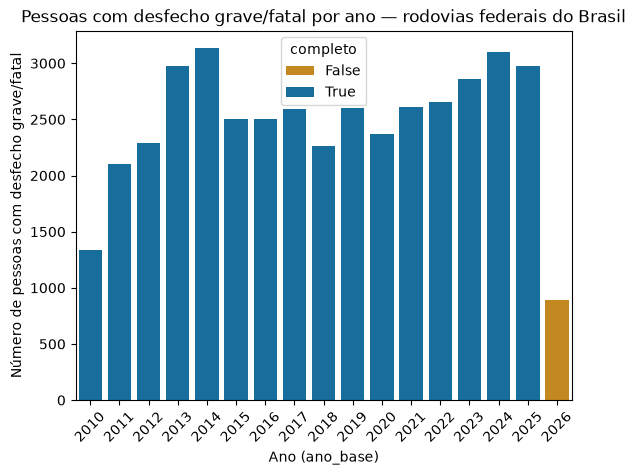

In [19]:
paleta = sns.color_palette("colorblind")

ax = sns.barplot(
    data=tendencia_anual,
    x="ano_base",
    y="n_grave_fatal",
    hue="completo",
    palette={True: paleta[0], False: paleta[1]},
    dodge=False,
)
ax.set(xlabel="Ano (ano_base)", ylabel="Número de pessoas com desfecho grave/fatal",
       title="Pessoas com desfecho grave/fatal por ano — rodovias federais do Brasil")
ax.tick_params(axis="x", rotation=45)

**Leitura do gráfico:** cada barra mostra o número absoluto de pessoas com desfecho grave/fatal
naquele ano (não o total de pessoas registradas). A barra de 2026, em cor diferente, sinaliza que
o ano está parcial na base — não deve ser lida como continuação da série.

##### Taxa de gravidade grave/fatal por ano

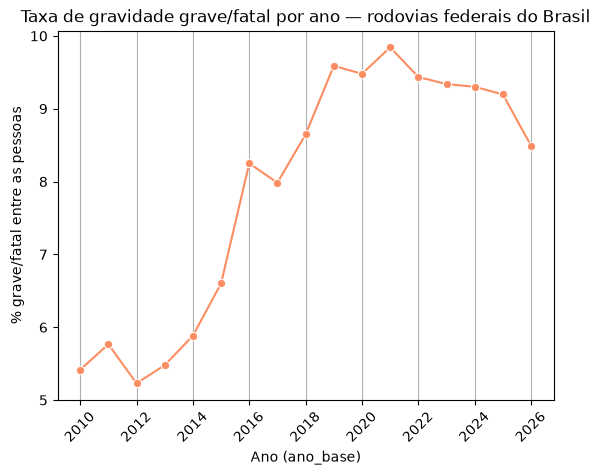

In [20]:
ax = sns.lineplot(data=tendencia_anual, x="ano_base", y="taxa_grave_fatal",
                   color=sns.color_palette("Set2")[1], marker="o")
ax.set(xlabel="Ano (ano_base)", ylabel="% grave/fatal entre as pessoas",
       title="Taxa de gravidade grave/fatal por ano — rodovias federais do Brasil")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="x")

**Leitura do gráfico:** cada ponto mostra a proporção de pessoas com desfecho grave/fatal entre as
pessoas com desfecho conhecido naquele ano. O ponto de 2026 está incluído na linha, mas o ano é
parcial na base e não deve ser interpretado como continuação da tendência.

**Interpretação:** O volume total de pessoas com desfecho conhecido cresceu de 24.707 (2010) até
um pico de 54.368 em 2013, caiu de forma acentuada a partir de 2015 e se estabilizou entre
aproximadamente 25 mil e 33 mil pessoas por ano de 2016 a 2025. Já o número absoluto de pessoas
com desfecho grave/fatal seguiu uma trajetória diferente: cresceu de 1.338 (2010) até 3.135 em
2014, caiu para 2.501 em 2015 e, ao contrário do volume total, se manteve relativamente estável
dali em diante — oscilando entre aproximadamente 2.260 e 2.860 até 2023, com um novo pico em 2024
(3.104). Esse descolamento entre as duas séries explica boa parte do comportamento da taxa: entre
2010 e 2012 ela oscilou sem tendência clara (5,42% → 5,77% → 5,23%), mas a partir de 2013 subiu de
forma praticamente contínua até atingir seu ponto mais alto em 2021 (9,84%) — no mesmo período em
que o total de pessoas registradas caiu, mas os casos graves/fatais não caíram na mesma proporção,
aumentando a fatia que representam. De 2022 a 2025, a taxa recuou de forma gradual e consistente
(9,44% → 9,20%), sem retornar aos patamares de antes de 2016. A leitura se restringe às pessoas com
desfecho conhecido (exclui "Ignorado") e é descritiva: não isola causas por trás dessa mudança de
composição, que poderiam incluir alterações na completude do registro de estado físico ao longo
dos anos, e não necessariamente uma piora real da segurança viária. O ano de 2026 (895 pessoas com
desfecho grave/fatal, taxa de 8,49%) está incompleto na base e por isso foi excluído da leitura de
tendência.

### Pergunta 2 - Em quais combinações de dia da semana e período do dia a gravidade observada é maior?


Investigamos se a proporção de gravidade grave/fatal varia conforme a combinação entre dia da semana e período do dia (madrugada, manhã, tarde, noite) do sinistro, nas rodovias federais do Brasil. Usamos a base `validos`, agrupada por `dia_semana` e `periodo_dia` simultaneamente, e aplicamos o limiar mínimo de observações (`N_MINIMO`) já definido no início do notebook, para evitar comparar combinações com poucos casos.

#### Taxa de gravidade grave/fatal por dia da semana e período do dia

In [21]:
gravidade_dia_periodo = (
    validos
    .groupby(["dia_semana", "periodo_dia"])["grave_fatal"]
    .agg(n_pessoas="size", n_grave_fatal="sum")
    .reset_index()
)

gravidade_dia_periodo["taxa_grave_fatal"] = (
    gravidade_dia_periodo["n_grave_fatal"] / gravidade_dia_periodo["n_pessoas"] * 100
)

gravidade_dia_periodo = gravidade_dia_periodo[gravidade_dia_periodo["n_pessoas"] >= N_MINIMO]

gravidade_dia_periodo

,dia_semana,periodo_dia,n_pessoas,n_grave_fatal,taxa_grave_fatal
0,DOMINGO,Madrugada,12938,1723,13.317360
1,DOMINGO,Manhã,19554,1792,9.164365
2,DOMINGO,Noite,29886,2576,8.619420
3,DOMINGO,Tarde,34515,2670,7.735767
4,QUARTA-FEIRA,Madrugada,4068,505,12.413963
5,QUARTA-FEIRA,Manhã,22025,1195,5.425653
6,QUARTA-FEIRA,Noite,16178,1037,6.409939
7,QUARTA-FEIRA,Tarde,22975,1470,6.398259
8,QUINTA-FEIRA,Madrugada,4674,574,12.280702
9,QUINTA-FEIRA,Manhã,23117,1390,6.012891


#### Mapa de calor

[Text(0.5, 23.185633680555554, 'Período do dia'),
 Text(50.833333333333314, 0.5, 'Dia da semana'),
 Text(0.5, 1.0, 'Taxa de gravidade grave/fatal por dia da semana e período do dia')]

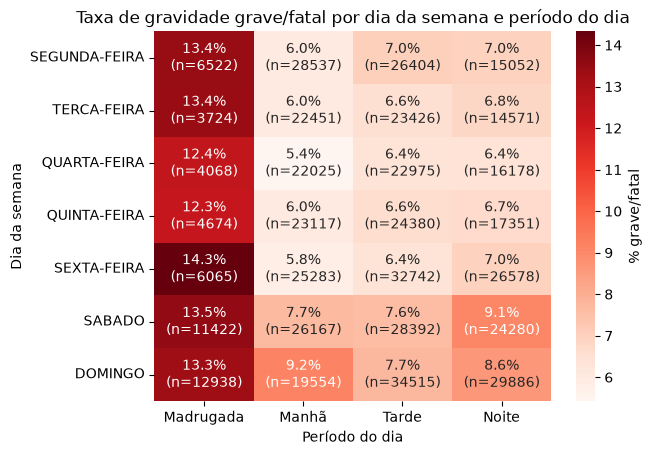

In [22]:
ORDEM_DIAS = ["SEGUNDA-FEIRA", "TERCA-FEIRA", "QUARTA-FEIRA", "QUINTA-FEIRA",
              "SEXTA-FEIRA", "SABADO", "DOMINGO"]
ORDEM_PERIODOS = ["Madrugada", "Manhã", "Tarde", "Noite"]

tabela_taxa = gravidade_dia_periodo.pivot(
    index="dia_semana", columns="periodo_dia", values="taxa_grave_fatal"
).reindex(index=ORDEM_DIAS, columns=ORDEM_PERIODOS)

tabela_n = gravidade_dia_periodo.pivot(
    index="dia_semana", columns="periodo_dia", values="n_pessoas"
).reindex(index=ORDEM_DIAS, columns=ORDEM_PERIODOS)

# monta o texto de cada célula: "8.5%\n(n=1234)"
anotacoes = tabela_taxa.round(1).astype(str) + "%\n(n=" + tabela_n.astype("Int64").astype(str) + ")"

ax = sns.heatmap(
    tabela_taxa, annot=anotacoes, fmt="", cmap="Reds",
    cbar_kws={"label": "% grave/fatal"},
)
ax.set(xlabel="Período do dia", ylabel="Dia da semana",
       title="Taxa de gravidade grave/fatal por dia da semana e período do dia")

**Leitura do gráfico**: cada célula mostra a proporção de gravidade grave/fatal (%, tom de cor) e o número de pessoas que sustentam esse cálculo (n, entre parênteses) para a combinação de dia da semana e período do dia. Tons mais escuros indicam maior proporção, não maior volume de pessoas. Como os valores de madrugada (12,3% a 14,3%) são bem mais altos que os demais períodos, a escala de cor faz as diferenças entre manhã, tarde e noite aparecerem mais sutis visualmente — nesses casos, a leitura deve se apoiar no valor numérico anotado em cada célula, não só na intensidade da cor. Todas as 28 combinações de dia e período têm amostra acima do mínimo definido (`N_MINIMO`), então nenhuma célula foi excluída por baixo volume.

**Interpretação:** Entre as 28 combinações de dia da semana e período do dia — todas com amostra acima do mínimo definido —, madrugada é sistematicamente o período de maior proporção de gravidade grave/fatal em todos os dias da semana, variando de 12,3% (quinta-feira, n=4.674) a 14,3% (sexta-feira, n=6.065), a maior proporção observada em toda a tabela. Fora da madrugada, as maiores proporções aparecem no fim de semana à noite e pela manhã: domingo de manhã (9,2%, n=19.554) e sábado à noite (9,1%, n=24.280) se destacam claramente acima dos demais horários de dias úteis, cujos valores variam entre 5,4% (menor, quarta-feira de manhã) e 7,0% (maior, presente em algumas combinações de segunda e sexta-feira). As menores proporções aparecem nas manhãs de dias úteis, com destaque para quarta-feira (5,4%, n=22.025) e sexta-feira (5,8%, n=25.283). O padrão sugere um efeito combinado entre horário de baixa luminosidade/movimento (madrugada) e comportamento de fim de semana, mas essa é uma leitura descritiva da composição do recorte — fatores associados a esses períodos (velocidade praticada, volume de tráfego, consumo de álcool, fiscalização, visibilidade) não estão controlados aqui e podem explicar total ou parcialmente a diferença observada.

### Pergunta 3 - Como a gravidade varia entre os diferentes tipos de sinistro?

O objetivo desta análise é investigar como a taxa de gravidade (proporção de feridos graves e óbitos) varia entre os diferentes tipos de acidentes registrados nas rodovias federais. Para garantir a consistência estatística, a análise é realizada sobre a base de dados filtrada validos (composta apenas por registros onde o desfecho da vítima é conhecido). A taxa percentual de vítimas graves/fatais foi calculada agrupando-se os dados por tipo_acidente, aplicando-se o parâmetro N_MINIMO para desconsiderar categorias com baixo volume de ocorrências que pudessem causar distorções percentuais.

In [23]:
taxa_tipo_acidente = taxa_por_categoria(validos, "tipo_acidente")
taxa_tipo_acidente

,n,positivos,taxa
tipo_acidente,,,
COLISAO FRONTAL,43740,14116,32.272519
SAIDA DE LEITO CARROCAVEL,41431,5561,13.422317
CAPOTAMENTO,27675,3267,11.804878
COLISAO LATERAL SENTIDO OPOSTO,6191,696,11.242126
SAIDA DE PISTA,36616,3541,9.670636
COLISAO COM OBJETO,10275,964,9.381995
COLISAO COM OBJETO ESTATICO,7162,646,9.019827
EVENTOS ATIPICOS,466,37,7.939914
TOMBAMENTO,3129,214,6.839246


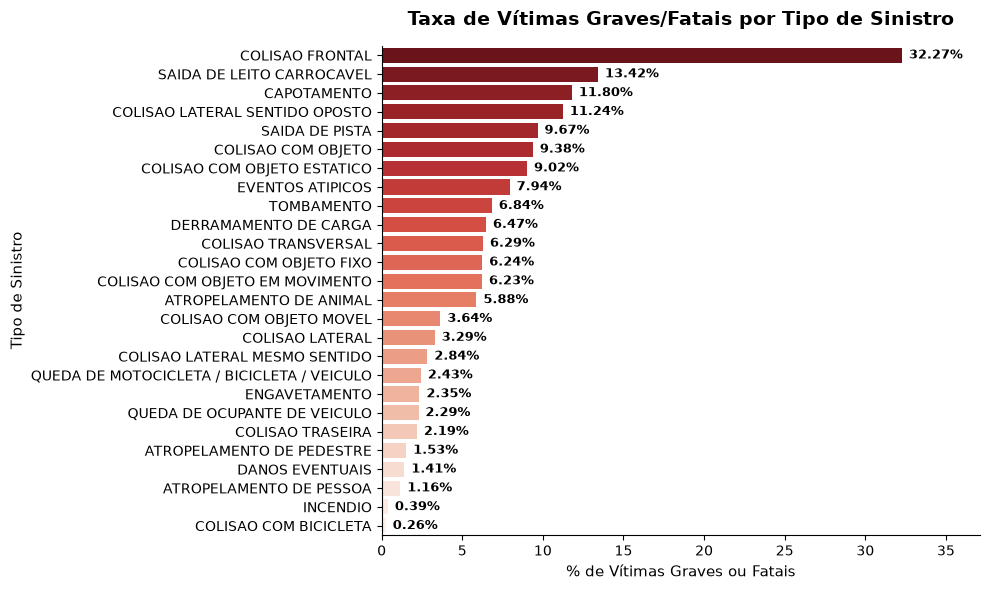

In [24]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=taxa_tipo_acidente.reset_index(),
    x="taxa",
    y="tipo_acidente",
    hue="tipo_acidente",
    palette="Reds_r",
    legend=False 
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.2f}%',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(5, 0), textcoords='offset points',
        fontsize=9, fontweight='bold', color='black'
    )

plt.title("Taxa de Vítimas Graves/Fatais por Tipo de Sinistro", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("% de Vítimas Graves ou Fatais", fontsize=11)
plt.ylabel("Tipo de Sinistro", fontsize=11)
plt.xlim(0, max(taxa_tipo_acidente['taxa']) * 1.15) 
sns.despine()
plt.tight_layout()
plt.show()

**Leitura do gráfico:** cada barra representa uma categoria de tipo_acidente, ordenada de forma decrescente pela proporção de vítimas graves ou fatais; o rótulo ao lado de cada barra indica o percentual exato (taxa) calculado sobre o total de envolvidos com desfecho conhecido naquele tipo de evento; a tabela de apoio apresenta o número absoluto de pessoas ($N$) e de casos severos (positivos), sendo que categorias com amostragem menor pedem leitura mais cautelosa. O objetivo é comparar a magnitude do risco entre as diferentes dinâmicas de impacto, e não estabelecer uma ordem causal direta.

**Interpretação:** A proporção de vítimas graves ou fatais varia amplamente entre os tipos de sinistro, indo de 2,19% até 32,27%. A Colisão Frontal destaca-se isoladamente com o maior índice de severidade (32,27%), impulsionada pela grande transferência de energia cinética no choque direto entre veículos em sentidos opostos. Em seguida, eventos de perda de controle como Saída de Leito Carroçável (13,42%) e Capotamento (11,80%) apresentam taxas intermediárias elevadas. Em contrapartida, a Colisão Traseira registra a menor gravidade (2,19%), apesar de concentrar o maior volume absoluto de envolvidos na base ($N = 176.690$), por ocorrer predominantemente em retenções ou velocidades reduzidas. A comparação é exploratória: fatores como velocidade média do trecho, tipo de veículo, uso de cinto de segurança e condições da via não estão controlados neste recorte e influenciam diretamente o desfecho do acidente.

### Pergunta 4 - Como condições da via e do ambiente (tipo de pista, uso do solo, fase do dia, condição meteorológica) se associam à gravidade?

Investigamos como fatores relacionados à via e ao ambiente — tipo de pista, uso do solo, fase do dia e condição meteorológica — se associam à proporção de vítimas graves/fatais. Usamos a base validos, calculando a taxa de grave_fatal para cada categoria dessas quatro variáveis, sempre exigindo o mínimo de observações definido em N_MINIMO. Os quatro painéis compartilham a mesma escala no eixo Y para permitir comparação direta entre eles.

In [25]:
taxa_tipo_pista = taxa_por_categoria(validos, "tipo_pista")
taxa_tipo_pista

,n,positivos,taxa
tipo_pista,,,
SIMPLES,279326,30496,10.917709
DUPLA,228583,10137,4.434713
MULTIPLA,45366,1152,2.539347


In [26]:
taxa_uso_solo = taxa_por_categoria(validos, "uso_solo")
taxa_uso_solo

,n,positivos,taxa
uso_solo,,,
RURAL,291158,32980,11.327183
URBANO,262117,8805,3.359187


In [27]:
taxa_fase_dia = taxa_por_categoria(validos, "fase_dia")
taxa_fase_dia

,n,positivos,taxa
fase_dia,,,
AMANHECER,23637,2912,12.319668
PLENA NOITE,156325,14168,9.063170
ANOITECER,33232,2209,6.647208
PLENO DIA,340074,22496,6.615031


In [28]:
taxa_condicao_metereologica = taxa_por_categoria(validos, "condicao_metereologica")
taxa_condicao_metereologica

,n,positivos,taxa
condicao_metereologica,,,
IGNORADO,2747,361,13.141609
NEVOEIRO/NEBLINA,4429,545,12.305261
VENTO,1096,113,10.310219
GAROA/CHUVISCO,10358,882,8.515157
CHUVA,83427,7047,8.446906
IGNORADA,3934,331,8.413828
CEU CLARO,293864,22568,7.679743
NUBLADO,92657,6551,7.070162
SOL,60690,3386,5.579173


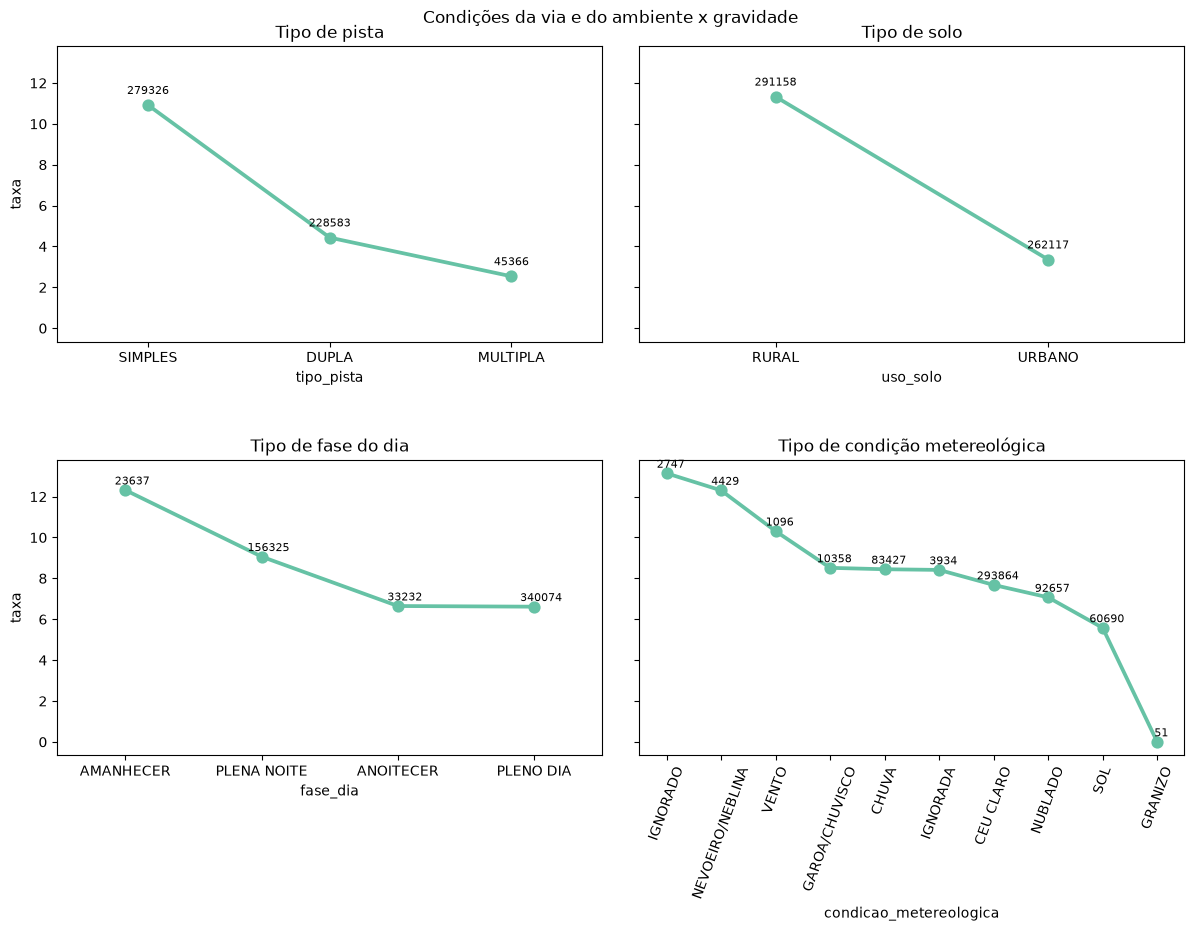

In [29]:
fig , axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8), sharey=True)

fig.suptitle("Condições da via e do ambiente x gravidade")
fig.tight_layout()
fig.subplots_adjust(hspace=0.4)

sns.pointplot(data=taxa_tipo_pista.reset_index(), x="tipo_pista", y="taxa", ax=axes[0, 0])
axes[0, 0].set_title("Tipo de pista")
for x, (_, linha) in enumerate(taxa_tipo_pista.iterrows()):
    axes[0 ,0].annotate(f"{int(linha["n"])}", (x, linha["taxa"]), textcoords="offset points",
                        xytext=(0,8), ha="center", fontsize=8)
                        

sns.pointplot(data=taxa_uso_solo.reset_index(), x="uso_solo", y="taxa", ax=axes[0, 1])
axes[0, 1].set_title("Tipo de solo")
for x, (_, linha) in enumerate(taxa_uso_solo.iterrows()):
    axes[0 ,1].annotate(f"{int(linha["n"])}", (x, linha["taxa"]), textcoords="offset points",
                        xytext=(0,8), ha="center", fontsize=8)
    

sns.pointplot(data=taxa_fase_dia.reset_index(), x="fase_dia", y="taxa", ax=axes[1, 0])
axes[1 , 0].set_title("Tipo de fase do dia")
for x, (_, linha) in enumerate(taxa_fase_dia.iterrows()):
    axes[1 ,0].annotate(f"{int(linha["n"])}", (x, linha["taxa"]), textcoords="offset points",
                        xytext=(5,4), ha="center", fontsize=8)
    

sns.pointplot(data=taxa_condicao_metereologica.reset_index(), x="condicao_metereologica", y="taxa", ax=axes[1, 1])
axes[1, 1].set_title("Tipo de condição metereológica")
axes[1, 1].tick_params(axis = 'x', rotation=70 )
for x, (_, linha) in enumerate(taxa_condicao_metereologica.iterrows()):
    axes[1 ,1].annotate(f"{int(linha["n"])}", (x, linha["taxa"]), textcoords="offset points",
                        xytext=(3,4), ha="center", fontsize=8)

**Leitura do gráfico:** cada painel representa uma variável do ambiente/via, com os pontos ordenados da maior para a menor taxa de gravidade; acima de cada ponto indica quantas pessoas sustentam aquela categoria. Como essas variáveis tendem a ocorrer em conjunto (por exemplo, pista simples é mais comum em áreas rurais e à noite), padrões parecidos entre painéis diferentes podem refletir sobreposição entre as próprias variáveis, não necessariamente efeitos independentes.

**Interpretação:** 

*Tipo de pista:* pista simples apresenta a maior proporção de gravidade (10,9%, n=279.326), quase o dobro da pista dupla (4,4%, n=228.583) e mais de quatro vezes a da pista múltipla (2,5%, n=45.366).

*Uso do solo:* áreas rurais têm taxa bem mais alta que áreas urbanas (11,3%, n=291.158 vs. 3,3%, n=262.117) — coerente com o padrão de pista simples acima, já que vias rurais tendem a ser predominantemente pista simples.

*Fase do dia:* amanhecer tem a maior proporção (12,3%, n=23.637), seguido por plena noite (9,0%, n=156.325); anoitecer e pleno dia ficam próximos e mais baixos (6,6% em ambos, com n=33.232 e n=340.074 respectivamente) — vale notar que amanhecer é a categoria com menor volume de casos entre as quatro, o que pede leitura mais cautelosa apesar de passar no filtro mínimo.

*Condição meteorológica:* nevoeiro/neblina tem a maior taxa (12,3%, n=4.429), mas com amostra pequena; granizo tem a menor taxa (0,1%, n=51), amostra ainda menor e deve ser lida com muita cautela. Entre as categorias com volume mais robusto, chuva (8,3%, n=83.427) e céu claro (7,6%, n=293.864) têm taxas relativamente próximas, sugerindo que a condição meteorológica isoladamente pode ter menor poder explicativo do que tipo de pista ou uso do solo.

Como já apontado, essas variáveis se sobrepõem na prática (pista simples, área rural e menor luminosidade tendem a coocorrer), então os resultados indicam associação descritiva, não relação causal isolada de cada fator.

### Pergunta 5 - Existe um gradiente descritivo entre a gravidade e a avaliação de segurança Latin NCAP / o valor de mercado FIPE dos veículos?

Investigamos se a gravidade observada acompanha algum padrão ao longo das faixas de segurança do Latin NCAP e das faixas de valor de mercado da Tabela FIPE. Usamos a base `veiculos`: uma linha por veículo, com o pior desfecho entre seus ocupantes, porque aqui comparamos *veículos* entre si, não pessoas.

##### Estrelas Latin NCAP (proteção para adultos)

Usamos o ponto médio entre `latin_ncap_estrelas_adulto_min` e `latin_ncap_estrelas_adulto_max` como
resumo da faixa de estrelas do veículo, já que o Latin NCAP costuma reportar uma faixa (por causa
de diferentes versões do mesmo modelo) em vez de um valor único. Agrupamos os veículos por esse
ponto médio e comparamos a proporção de desfecho grave/fatal entre as faixas, sempre exigindo o
mínimo de observações definido em `N_MINIMO` para não comparar faixas com poucos veículos.

In [30]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def grafico_gradiente(dados, coluna_x, xlabel, titulo):
    dados = dados.reset_index()
    norm = mcolors.Normalize(vmin=dados["taxa"].min(), vmax=dados["taxa"].max())
    cores = cm.Reds(norm(dados["taxa"]))
    media_geral = dados["taxa"].mean()

    plt.figure(figsize=(9, 5))
    plt.scatter(dados[coluna_x], dados["taxa"], c=cores, s=140, zorder=3,
                edgecolor="black", linewidth=0.6)
    plt.axhline(media_geral, color="gray", linestyle="--", linewidth=1,
                label=f"média das faixas ({media_geral:.1f}%)")
    for _, linha in dados.iterrows():
        plt.annotate(f"n={int(linha['n'])}", (linha[coluna_x], linha["taxa"]),
                     textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)

    plt.xlabel(xlabel)
    plt.ylabel("% grave/fatal entre os veículos")
    plt.title(titulo)
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

In [31]:
gradiente_estrelas = taxa_por_categoria(
    veiculos, "latin_ncap_estrelas_adulto_media",
    coluna_alvo="grave_fatal_veiculo", minimo=N_MINIMO,
).sort_index()

gradiente_estrelas

,n,positivos,taxa
latin_ncap_estrelas_adulto_media,,,
0.0,15808,1043,6.597925
1.0,119730,8774,7.328155
1.5,22184,1464,6.599351
2.0,87834,5787,6.588565
2.5,887,42,4.735062
3.0,24773,1789,7.221572
3.5,8022,535,6.669160
4.0,68566,4234,6.175072
4.5,7363,421,5.717778


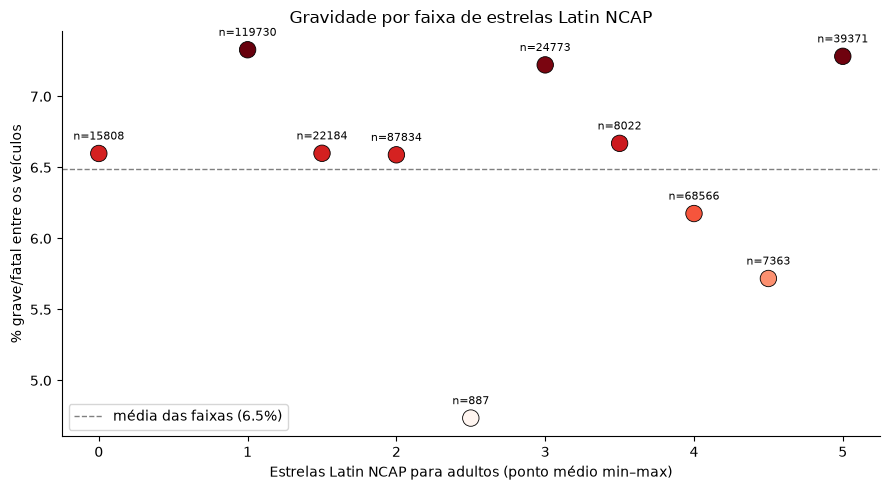

In [32]:
grafico_gradiente(
    gradiente_estrelas, "latin_ncap_estrelas_adulto_media",
    xlabel="Estrelas Latin NCAP para adultos (ponto médio min–max)",
    titulo="Gravidade por faixa de estrelas Latin NCAP",
)

**Leitura do gráfico:** cada ponto é uma faixa de estrelas (incrementos de 0,5, porque é a média de
dois valores inteiros); o `n=` acima de cada ponto mostra quantos veículos sustentam aquela faixa;
faixas com `n` baixo pedem leitura mais cautelosa. A linha tracejada marca a média entre as faixas: quanto mais os pontos oscilam em torno dela sem um padrão de queda, menos evidência há de um gradiente real. Não há expectativa de queda contínua entre as faixas: o objetivo é descrever a forma da relação, não confirmar uma tendência.

**Interpretação:** A proporção de gravidade grave/fatal varia numa faixa relativamente estreita
(entre 4,7% e 7,3%) ao longo dos níveis de estrelas Latin NCAP, sem um gradiente descendente claro
conforme a avaliação de segurança aumenta. O ponto de menor proporção (2,5 estrelas) tem amostra
pequena (n=887) frente às demais faixas e deve ser lido com cautela. Notavelmente, a faixa de maior
avaliação (5,0 estrelas, n=39.371) apresenta proporção próxima à da faixa de menor avaliação (1,0
estrela, n=119.730), o que não sustenta, neste recorte, uma relação simples entre mais estrelas e
menor gravidade. A comparação é exploratória: preço, idade do veículo, ano, protocolo de teste e
contexto do sinistro não estão controlados aqui e podem estar relacionados tanto às estrelas quanto
à gravidade.

##### Decis de preço FIPE

Usamos `decil_preco_fipe` (já calculado na base `veiculos` a partir do preço mediano da FIPE) para
comparar a gravidade entre faixas de valor de mercado do veículo. Por ser baseado em decis, cada
faixa tem, em teoria, o mesmo número de veículos, exceto quando há muitos valores empatados, que
podem reduzir o número efetivo de grupos distintos.

In [33]:
gradiente_preco = taxa_por_categoria(
    veiculos, "decil_preco_fipe",
    coluna_alvo="grave_fatal_veiculo", minimo=N_MINIMO,
).sort_index()

gradiente_preco

,n,positivos,taxa
decil_preco_fipe,,,
1.0,39639,2612,6.589470
2.0,39672,2892,7.289776
3.0,43043,2814,6.537648
4.0,35711,2620,7.336675
5.0,39327,2566,6.524779
6.0,39934,2690,6.736115
7.0,38618,2467,6.388213
8.0,39835,2750,6.903477
9.0,39080,2641,6.757932


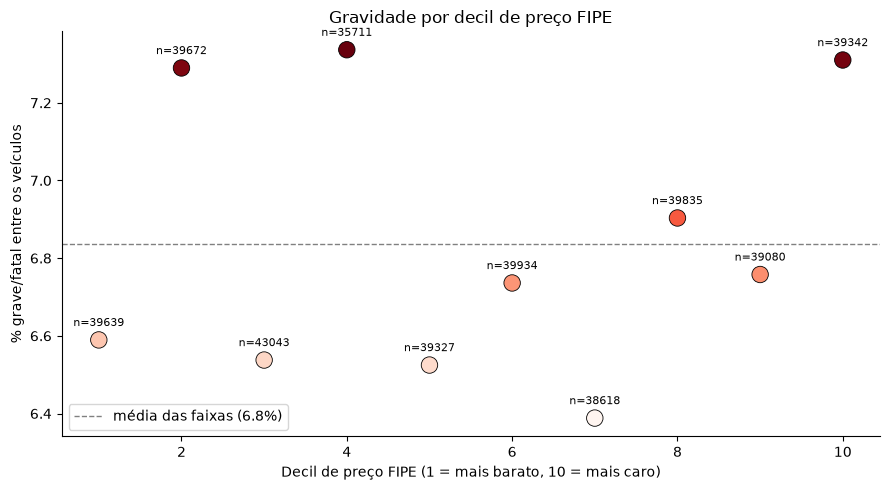

In [34]:
grafico_gradiente(
    gradiente_preco, "decil_preco_fipe",
    xlabel="Decil de preço FIPE (1 = mais barato, 10 = mais caro)",
    titulo="Gravidade por decil de preço FIPE",
)

**Interpretação:** A proporção de gravidade grave/fatal também varia numa faixa estreita entre os
decis de preço FIPE (6,39% a 7,34%), sem tendência clara de queda conforme o valor do veículo
aumenta. O decil 4 tem a maior proporção (7,34%, n=35.711) e o decil 7 a menor (6,39%, n=38.618),
mas os valores intermediários oscilam sem um padrão monotônico visível. Os n ficaram equilibrados
entre os dez grupos (entre 35 e 43 mil veículos cada), então a oscilação não parece efeito de
amostra pequena em nenhum decil específico. Assim como no gradiente de estrelas, o resultado não
sustenta, neste recorte, uma associação simples entre valor de mercado e menor gravidade. A
comparação segue exploratória: características do veículo, do trajeto e do sinistro não estão
controladas nesta etapa.

### Pergunta 6 - Essa associação se sustenta em uma regressão linear com controles observáveis?

A Pergunta 5 mostrou que, olhando estrelas Latin NCAP e preço FIPE isoladamente, a gravidade oscila numa faixa estreita e sem um padrão claro de queda. Isso não significa necessariamente que essas variáveis não importam. É possível que o efeito delas esteja sendo mascarado por outras características que variam junto, como o fato de veículos mais seguros ou mais caros circularem com mais frequência em vias urbanas, que já são menos graves por conta própria.

Para verificar essa possibilidade, ajustamos um modelo de regressão linear que estima o coeficiente de cada variável controlando pelas demais ao mesmo tempo. A ideia é a mesma de uma regressão linear simples, que ajusta uma reta minimizando o erro quadrático médio entre a reta e os pontos observados, só que aqui o ajuste é feito para várias variáveis de uma vez, e não apenas para uma.

#### Preparação da amostra do modelo

Usamos a base `veiculos`, filtrada para `ano_base <= ANO_MAXIMO_COMPLETO` (2026 é parcial). Entram no modelo as variáveis numéricas estrelas Latin NCAP, airbags, preço FIPE (log), idade do veículo e ano do sinistro, além das categóricas fase do dia, tipo de pista e uso do solo. Linhas incompletas são removidas apenas nessas colunas, para não descartar veículos por ausência em campos que não entram no modelo.

In [35]:
COLUNAS_NUMERICAS_MODELO = [
    "latin_ncap_estrelas_adulto_media",
    "latin_ncap_airbags_media",
    "log_fipe_valor_mediano",
    "idade_veiculo",
    "ano_base",
]
COLUNAS_CATEGORICAS_MODELO = ["fase_dia", "tipo_pista", "uso_solo"]
COLUNA_ALVO_MODELO = "grave_fatal_veiculo"

colunas_necessarias_modelo = COLUNAS_NUMERICAS_MODELO + COLUNAS_CATEGORICAS_MODELO + [COLUNA_ALVO_MODELO]

modelo_base = veiculos[veiculos["ano_base"] <= ANO_MAXIMO_COMPLETO].copy()
for coluna in COLUNAS_CATEGORICAS_MODELO:
    print(f"--- {coluna} ---")
    print(modelo_base[coluna].value_counts(dropna=False))
    print()

--- fase_dia ---
fase_dia
PLENO DIA      241067
PLENA NOITE    108636
ANOITECER       23918
AMANHECER       15792
(NULL)              9
Name: count, dtype: int64

--- tipo_pista ---
tipo_pista
SIMPLES     181671
DUPLA       171194
MULTIPLA     36554
(NULL)           3
Name: count, dtype: int64

--- uso_solo ---
uso_solo
URBANO    210473
RURAL     178946
NaN            3
Name: count, dtype: int64



In [36]:
VALORES_INVALIDOS_CATEGORICOS = ["(NULL)", "NULL", "NAN", "NONE", ""]

for coluna in COLUNAS_CATEGORICAS_MODELO:
    modelo_base[coluna] = modelo_base[coluna].replace(VALORES_INVALIDOS_CATEGORICOS, np.nan)

modelo_base = modelo_base.dropna(subset=colunas_necessarias_modelo)
modelo_base[COLUNA_ALVO_MODELO] = modelo_base[COLUNA_ALVO_MODELO].astype(int)

print("Veículos no modelo:", len(modelo_base), "de", len(veiculos), "na base veiculos original")

Veículos no modelo: 389096 de 394538 na base veiculos original


#### Ajuste do modelo (com controles)

A regressão linear simples ajusta uma reta, f(x) = ax + b, minimizando o erro quadrático médio entre a reta e os pontos observados. A regressão linear múltipla segue a mesma ideia, mas com mais de uma variável explicativa: f(x1, ..., xk) = b0 + b1x1 + ... + bkxk, também ajustada minimizando o erro quadrático médio. Com mais de uma variável não é possível usar a fórmula fechada de a e b da regressão simples, então o ajuste é resolvido por álgebra matricial. É isso que a biblioteca `statsmodels` faz por trás da função `smf.ols` (Ordinary Least Squares, ou mínimos quadrados ordinários, o nome técnico do método). O modelo continua sendo uma regressão linear: uma combinação linear das variáveis, ajustada minimizando o erro quadrático, agora com várias variáveis ao mesmo tempo em vez de apenas uma.

As variáveis categóricas (fase do dia, tipo de pista, uso do solo) entram no modelo como variáveis indicadoras (dummies), cada uma comparada a uma categoria de referência.

In [37]:
import re
import statsmodels.formula.api as smf

REFERENCIAS_MODELO = {
    "fase_dia": "PLENO DIA",
    "tipo_pista": "DUPLA",
    "uso_solo": "RURAL",
}

FORMULA_MODELO = (
    "grave_fatal_veiculo ~ latin_ncap_estrelas_adulto_media + latin_ncap_airbags_media "
    "+ log_fipe_valor_mediano + idade_veiculo + ano_base "
    "+ C(fase_dia, Treatment('PLENO DIA')) "
    "+ C(tipo_pista, Treatment('DUPLA')) "
    "+ C(uso_solo, Treatment('RURAL'))"
)

modelo = smf.ols(FORMULA_MODELO, data=modelo_base).fit()

def limpar_nome_variavel(nome):
    correspondencia = re.match(r"C\(([\w]+).*\)\[T\.(.*)\]", nome)
    if correspondencia:
        return f"{correspondencia.group(1)}={correspondencia.group(2)}"
    return "intercepto" if nome == "Intercept" else nome

resultado_modelo = pd.DataFrame({
    "variavel": [limpar_nome_variavel(nome) for nome in modelo.params.index],
    "coeficiente": modelo.params.values,
})
resultado_modelo["coeficiente_pp"] = resultado_modelo["coeficiente"] * 100

print("n do modelo:", len(modelo_base))
print("R²:", round(modelo.rsquared, 4))
print("Categorias de referência:", REFERENCIAS_MODELO)
resultado_modelo

n do modelo: 389096
R²: 0.0447
Categorias de referência: {'fase_dia': 'PLENO DIA', 'tipo_pista': 'DUPLA', 'uso_solo': 'RURAL'}


,variavel,coeficiente,coeficiente_pp
0,intercepto,-5.461372,-546.137192
1,fase_dia=AMANHECER,0.045182,4.518197
2,fase_dia=ANOITECER,0.000040,0.003952
3,fase_dia=PLENA NOITE,0.020754,2.075417
4,tipo_pista=MULTIPLA,-0.005827,-0.582712
5,tipo_pista=SIMPLES,0.044022,4.402157
6,uso_solo=URBANO,-0.065116,-6.511626
7,latin_ncap_estrelas_adulto_media,-0.002720,-0.271987
8,latin_ncap_airbags_media,0.000034,0.003388
9,log_fipe_valor_mediano,-0.009023,-0.902290


#### Gráfico dos coeficientes

Cada linha representa uma variável do modelo (o intercepto não é mostrado). A posição do ponto indica o coeficiente em pontos percentuais: verde quando positivo, associado a mais gravidade, e vermelho quando negativo, associado a menos gravidade. A linha vertical em zero serve de referência. Para as variáveis categóricas, o coeficiente é sempre lido em relação à categoria de referência (por exemplo, "fase_dia=NOITE" compara a fase noite com pleno dia, que é a referência).

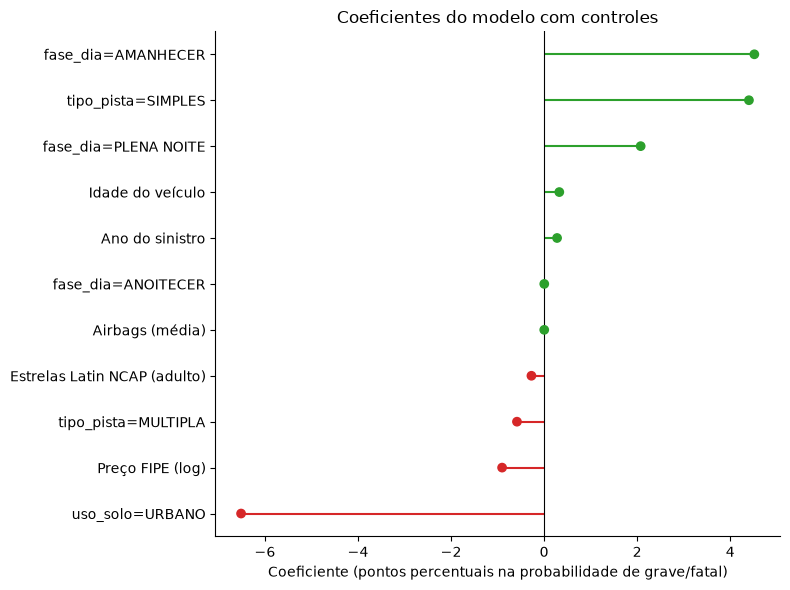

In [38]:
NOMES_AMIGAVEIS = {
    "latin_ncap_estrelas_adulto_media": "Estrelas Latin NCAP (adulto)",
    "latin_ncap_airbags_media": "Airbags (média)",
    "log_fipe_valor_mediano": "Preço FIPE (log)",
    "idade_veiculo": "Idade do veículo",
    "ano_base": "Ano do sinistro",
}

coeficientes_grafico = (
    resultado_modelo[resultado_modelo["variavel"] != "intercepto"]
    .assign(rotulo=lambda d: d["variavel"].map(lambda v: NOMES_AMIGAVEIS.get(v, v)))
    .sort_values("coeficiente_pp")
)
cores_coeficientes = ["#2ca02c" if valor >= 0 else "#d62728" for valor in coeficientes_grafico["coeficiente_pp"]]

plt.figure(figsize=(8, 6))
plt.hlines(y=coeficientes_grafico["rotulo"], xmin=0, xmax=coeficientes_grafico["coeficiente_pp"], color=cores_coeficientes)
plt.scatter(coeficientes_grafico["coeficiente_pp"], coeficientes_grafico["rotulo"], color=cores_coeficientes, zorder=3)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (pontos percentuais na probabilidade de grave/fatal)")
plt.title("Coeficientes do modelo com controles")
sns.despine()
plt.tight_layout()
plt.show()

#### Sensibilidade: amostra restrita à maior confiança de pareamento disponível

O pareamento com o Latin NCAP tem um campo de confiança (`confianca_latin_ncap`). Os valores presentes na base são `baixa` e `media`; não existe `alta` neste recorte. Comparamos o modelo completo com o modelo restrito apenas aos pareamentos `media`, que é a maior confiança disponível.

In [39]:
modelo_base["confianca_latin_ncap"].value_counts(dropna=False)

confianca_latin_ncap
baixa    319886
media     69210
Name: count, dtype: int64

In [40]:
CATEGORIAS_CONFIANCA_ALTA = ["media"]
modelo_base_confianca = modelo_base[modelo_base["confianca_latin_ncap"].isin(CATEGORIAS_CONFIANCA_ALTA)]

modelo_confianca = smf.ols(FORMULA_MODELO, data=modelo_base_confianca).fit()

resultado_confianca = pd.DataFrame({
    "variavel": [limpar_nome_variavel(nome) for nome in modelo_confianca.params.index],
    "coeficiente_pp": modelo_confianca.params.values * 100,
})

print("n (todos os pareamentos):", len(modelo_base), "| R²:", round(modelo.rsquared, 4))
print("n (confiança média, a maior disponível):", len(modelo_base_confianca), "| R²:", round(modelo_confianca.rsquared, 4))

resultado_modelo[["variavel", "coeficiente_pp"]].merge(
    resultado_confianca, on="variavel", suffixes=("_todos", "_confianca_media")
)

n (todos os pareamentos): 389096 | R²: 0.0447
n (confiança média, a maior disponível): 69210 | R²: 0.0424


,variavel,coeficiente_pp_todos,coeficiente_pp_confianca_media
0,intercepto,-546.137192,-491.155817
1,fase_dia=AMANHECER,4.518197,4.934316
2,fase_dia=ANOITECER,0.003952,0.198094
3,fase_dia=PLENA NOITE,2.075417,1.931190
4,tipo_pista=MULTIPLA,-0.582712,-0.852330
5,tipo_pista=SIMPLES,4.402157,4.355596
6,uso_solo=URBANO,-6.511626,-6.752051
7,latin_ncap_estrelas_adulto_media,-0.271987,-0.115604
8,latin_ncap_airbags_media,0.003388,-0.060615
9,log_fipe_valor_mediano,-0.902290,-1.008317


**Interpretação:** Controlando pelas demais variáveis, estrelas Latin NCAP (-0,27 pp por estrela) e preço FIPE em log (-0,90 pp) aparecem com coeficiente negativo, ou seja, mais segurança ou mais valor está associado a menos gravidade. Isso é diferente do que a Pergunta 5 mostrou: lá, olhando essas duas variáveis sozinhas, não dava pra ver nenhum padrão claro. O efeito parece estar escondido, no recorte simples, por outras características que andam junto com segurança e preço. Por exemplo, veículos mais seguros ou mais caros tendem a rodar mais em vias urbanas, que já são menos graves por conta própria (uso_solo=URBANO tem o maior coeficiente do modelo, -6,51 pp). As variáveis que mais pesam no modelo são as do contexto do sinistro e da via, não as do veículo: fase_dia=AMANHECER (+4,52 pp), tipo_pista=SIMPLES (+4,40 pp) e fase_dia=PLENA NOITE (+2,08 pp). O R² é baixo (0,0447), o que já era esperado, já que poucas variáveis dificilmente explicam bem um desfecho raro e com muitas causas possíveis. Isso não deve ser lido como uma medida de qualidade do modelo, e o resultado mostra associação, não causa.

Restringindo a amostra aos pareamentos de confiança média (a maior disponível), o n cai de 389.096 para 69.210 e o R² fica praticamente igual (0,0424 contra 0,0447). Os coeficientes de estrelas Latin NCAP (-0,12 pp) e de preço FIPE (-1,01 pp) continuam com o mesmo sinal do modelo completo, embora o de estrelas fique bem menor (de -0,27 para -0,12 pp). Os coeficientes de fase do dia, tipo de pista e uso do solo continuam praticamente iguais nas duas amostras. Essa estabilidade é um bom sinal, mostra que o resultado não depende só dos pareamentos menos confiáveis. Mas o n bem menor na amostra restrita aumenta a incerteza das estimativas, principalmente a de estrelas, que foi a que mais mudou. De novo, essa comparação mostra associação, não prova causa.

**Limitações do modelo:** as previsões de um modelo linear de probabilidade podem cair fora do intervalo de 0 a 1; os resíduos são heterocedásticos por construção (a variância do erro depende do valor predito); há variáveis relevantes não observadas (ex.: velocidade no momento do sinistro, uso de cinto); e o pareamento com o Latin NCAP e a FIPE tem incerteza própria, discutida na seção de confiança acima. O modelo descreve associação condicional entre as variáveis observadas, não isola o efeito causal de nenhuma delas.

### Pergunta 7 - Onde os casos graves/fatais se concentram geograficamente?

A análise usa a base nacional `validos`, cuja unidade é a pessoa com `estado_fisico` conhecido. Mantemos 2010–2026; 2026 está parcial. Para municípios, medimos concentração pelo número absoluto de pessoas com desfecho grave/fatal e usamos a taxa apenas como contexto. Para BRs, comparamos a proporção grave/fatal, exigindo `N_MINIMO = 30`. Essas medidas não estimam risco geográfico, pois não há denominadores de exposição ao tráfego.

In [ ]:
# Diagnóstico da base comum, sem alterar validos nem as colunas geográficas originais
VALORES_GEOGRAFICOS_INVALIDOS = ["(NULL)", "NULL", "NAN", "NONE", ""]

diagnostico_p7 = pd.Series({
    "unidade": "pessoa com estado_fisico conhecido",
    "n_pessoas": len(validos),
    "n_grave_fatal": int(validos["grave_fatal"].sum()),
    "anos": f"{int(validos['ano_base'].min())}–{int(validos['ano_base'].max())} (2026 parcial)",
    "n_ufs_brutas": validos["uf"].nunique(dropna=True),
    "filtro_uf_aplicado": "não; recorte nacional",
    "grave_fatal_confere": validos["grave_fatal"].equals(
        validos["estado_fisico"].isin(["Ferido Grave", "Óbito"])
    ),
})

ausencias_geografia_p7 = pd.DataFrame({
    "ausentes_nativos": validos[["uf", "municipio", "br"]].isna().sum(),
    "marcadores_invalidos": {
        coluna: validos[coluna].astype("string").str.strip().str.upper()
        .isin(VALORES_GEOGRAFICOS_INVALIDOS).sum()
        for coluna in ["uf", "municipio", "br"]
    },
})

display(diagnostico_p7.to_frame("valor"))
display(ausencias_geografia_p7)


#### Concentração absoluta por município e UF

In [ ]:
# Cópias auxiliares tratam marcadores textuais de ausência sem substituir os campos originais
base_municipal_p7 = validos.assign(
    uf_p7=validos["uf"].astype("string").str.strip().str.upper(),
    municipio_p7=validos["municipio"].astype("string").str.strip(),
)
base_municipal_p7[["uf_p7", "municipio_p7"]] = base_municipal_p7[
    ["uf_p7", "municipio_p7"]
].replace(VALORES_GEOGRAFICOS_INVALIDOS, pd.NA)

municipios_excluidos_p7 = base_municipal_p7[["uf_p7", "municipio_p7"]].isna().any(axis=1)
tabela_municipios = (
    base_municipal_p7.loc[~municipios_excluidos_p7]
    .groupby(["uf_p7", "municipio_p7"])["grave_fatal"]
    .agg(n="size", positivos="sum")
    .reset_index()
)
tabela_municipios["taxa"] = tabela_municipios["positivos"] / tabela_municipios["n"] * 100
tabela_municipios["municipio_uf"] = (
    tabela_municipios["municipio_p7"] + " - " + tabela_municipios["uf_p7"]
)
tabela_municipios = tabela_municipios.sort_values(
    ["positivos", "n", "municipio_uf"], ascending=[False, False, True]
).reset_index(drop=True)

N_MUNICIPIOS_GRAFICO = 15
tabela_municipios_grafico = tabela_municipios.head(N_MUNICIPIOS_GRAFICO).copy()

reconciliacao_municipal_p7 = pd.Series({
    "pessoas_em_municipios_validos": int(tabela_municipios["n"].sum()),
    "pessoas_sem_municipio_uf_valido": int(municipios_excluidos_p7.sum()),
    "total_reconciliado": int(tabela_municipios["n"].sum() + municipios_excluidos_p7.sum()),
    "total_em_validos": len(validos),
    "confere": int(tabela_municipios["n"].sum() + municipios_excluidos_p7.sum()) == len(validos),
})

display(reconciliacao_municipal_p7.to_frame("valor"))
display(tabela_municipios_grafico[["municipio_uf", "n", "positivos", "taxa"]])


In [ ]:
plt.figure(figsize=(10, 7))
ax = sns.barplot(
    data=tabela_municipios_grafico,
    x="positivos", y="municipio_uf",
    hue="municipio_uf", palette="Reds_r", legend=False,
)
for barra, (_, linha) in zip(ax.patches, tabela_municipios_grafico.iterrows()):
    ax.annotate(
        f"{int(linha['positivos'])} (n={int(linha['n'])})",
        (barra.get_width(), barra.get_y() + barra.get_height() / 2),
        xytext=(5, 0), textcoords="offset points", va="center", fontsize=8,
    )
ax.set(
    xlabel="Pessoas com desfecho grave/fatal",
    ylabel="Município - UF",
    title=(f"{N_MUNICIPIOS_GRAFICO} municípios com maior concentração de casos graves/fatais\n"
           "Rodovias federais do Brasil, 2010–2026 (2026 parcial); unidade: pessoa"),
)
ax.set_xlim(0, tabela_municipios_grafico["positivos"].max() * 1.35)
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
cinco_municipios_p7 = tabela_municipios.head(5)
casos_top5_p7 = int(cinco_municipios_p7["positivos"].sum())
total_nacional_grave_fatal_p7 = int(validos["grave_fatal"].sum())
participacao_top5_p7 = casos_top5_p7 / total_nacional_grave_fatal_p7 * 100

display(cinco_municipios_p7[["municipio_uf", "n", "positivos", "taxa"]])
print(
    f"Participação dos cinco primeiros: {casos_top5_p7:,} / "
    f"{total_nacional_grave_fatal_p7:,} = {participacao_top5_p7:.2f}% dos casos nacionais."
)


**Leitura do gráfico:** as barras estão ordenadas pelo número absoluto de pessoas com desfecho grave/fatal; `n` informa todas as pessoas com desfecho conhecido naquela combinação de município e UF. Brasília - DF lidera com 390 casos, seguida de Serra - ES (226), Porto Velho - RO (220), Curitiba - PR (209) e Campo Grande - MS (192). Juntas, essas cinco combinações somam 1.237 dos 41.785 casos nacionais (2,96%). A taxa municipal aparece na tabela somente como contexto e não define o ranking.

**Interpretação:** no recorte nacional analisado, os registros graves/fatais estão distribuídos por muitos municípios: mesmo os cinco maiores volumes representam menos de 3% do total. Isso descreve concentração de casos, não identifica o “município mais perigoso”. Sem fluxo de veículos, extensão percorrida ou veículos-quilômetro, não é possível transformar os volumes em risco municipal. A inclusão de 2026, ainda parcial, está explícita e mantém a mesma base comum usada nas análises não temporais.

#### Proporção grave/fatal por BR

In [ ]:
print("Tipo original de br:", validos["br"].dtype)

def rotulo_br_p7(valor):
    if pd.isna(valor):
        return pd.NA
    texto = str(valor).strip().upper()
    if texto in VALORES_GEOGRAFICOS_INVALIDOS:
        return pd.NA
    numero = pd.to_numeric(texto, errors="coerce")
    if pd.notna(numero) and float(numero).is_integer():
        texto = str(int(numero))
    return f"BR-{texto}"

base_br_p7 = validos.assign(br_rotulo_p7=validos["br"].map(rotulo_br_p7))
brs_excluidas_p7 = base_br_p7["br_rotulo_p7"].isna()
tabela_brs = (
    base_br_p7.loc[~brs_excluidas_p7]
    .groupby("br_rotulo_p7")["grave_fatal"]
    .agg(n="size", positivos="sum")
    .reset_index()
)
tabela_brs["taxa"] = tabela_brs["positivos"] / tabela_brs["n"] * 100
tabela_brs_elegiveis = tabela_brs[tabela_brs["n"] >= N_MINIMO].sort_values(
    ["taxa", "n", "br_rotulo_p7"], ascending=[False, False, True]
).reset_index(drop=True)

print(
    f"BRs elegíveis: {len(tabela_brs_elegiveis)} | N_MINIMO={N_MINIMO} | "
    f"pessoas sem BR válida: {int(brs_excluidas_p7.sum())}"
)
with pd.option_context("display.max_rows", None):
    display(tabela_brs_elegiveis[["br_rotulo_p7", "n", "positivos", "taxa"]])


In [ ]:
N_BRS_GRAFICO = 20
brs_grafico_p7 = tabela_brs_elegiveis.head(N_BRS_GRAFICO)

plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=brs_grafico_p7,
    x="taxa", y="br_rotulo_p7",
    hue="br_rotulo_p7", palette="Reds_r", legend=False,
)
for barra, (_, linha) in zip(ax.patches, brs_grafico_p7.iterrows()):
    ax.annotate(
        f"{linha['taxa']:.1f}% (n={int(linha['n'])})",
        (barra.get_width(), barra.get_y() + barra.get_height() / 2),
        xytext=(5, 0), textcoords="offset points", va="center", fontsize=8,
    )
ax.set(
    xlabel="% grave/fatal entre as pessoas com desfecho conhecido",
    ylabel="Rodovia federal",
    title=(f"{N_BRS_GRAFICO} maiores proporções observadas por BR (N_MINIMO={N_MINIMO})\n"
           "Brasil, 2010–2026 (2026 parcial); unidade: pessoa"),
)
ax.set_xlim(0, brs_grafico_p7["taxa"].max() * 1.35)
sns.despine()
plt.tight_layout()
plt.show()


**Leitura do gráfico:** o painel mostra as 20 maiores proporções entre as 109 BRs que atendem a `N_MINIMO = 30`; a tabela anterior preserva o painel elegível completo. A BR-349 apresenta a maior proporção observada (25,93%, n=135), seguida da BR-412 (21,83%, n=197) e da BR-259 (20,08%, n=762). A ordenação usa a taxa, e os rótulos `n` ajudam a distinguir estimativas sustentadas por volumes diferentes.

**Interpretação:** as diferenças entre BRs são uma associação descritiva no recorte nacional analisado. Elas mostram a proporção observada de pessoas com desfecho grave/fatal entre os registros de cada rodovia elegível, não “BRs de maior risco”. O limiar mínimo evita taxas baseadas em pouquíssimas pessoas, mas não controla composição dos sinistros, trechos percorridos, fluxo, extensão ou fiscalização. Portanto, o painel complementa a concentração absoluta municipal sem misturar pessoas, veículos e sinistros no denominador.

### Pergunta 8 - Como essa relação varia entre tipos de sinistro, e quão sensível é ao critério de pareamento com o Latin NCAP?